# Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords

In [2]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [3]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to C:\Users\HP
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Load Dataset

In [4]:
df = pd.read_csv("../data/processed/amazon_reviews_cleaned.csv")

# General Overview

In [5]:
print("Number of reviews:", df.shape[0])
print("Number of unique products:", df['asins'].nunique())
print("Number of unique brands:", df['brand'].nunique())
print("Number of unique categories:", df['category'].nunique())

Number of reviews: 67807
Number of unique products: 82
Number of unique brands: 6
Number of unique categories: 98


In [6]:
# Check missing values
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 id                        0
product_name           6695
asins                     0
brand                     0
category                  0
keys                      0
manufacturer              0
review_date               0
reviews.dateSeen          0
do_recommend          12655
reviews.numHelpful    12593
rating                    0
reviews.sourceURLs        0
review_text               0
review_title             19
reviews.username         13
sentiment                 0
clean_text                5
dtype: int64


# Univariate Analysis

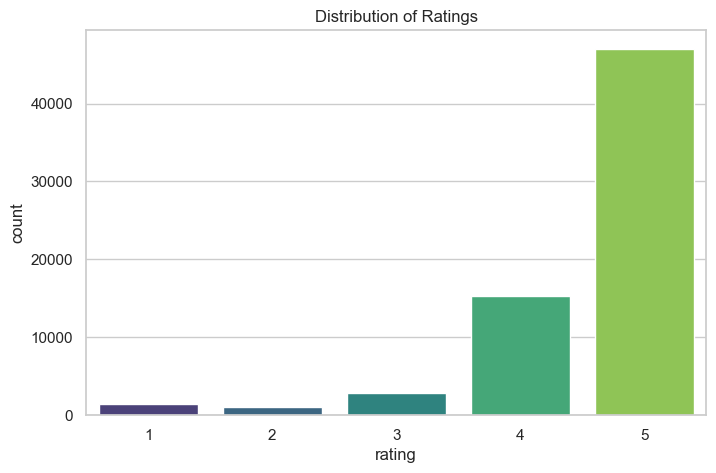

In [7]:
# Rating Distribution
plt.figure(figsize=(8,5))
sns.countplot(x='rating', data=df, palette='viridis')
plt.title("Distribution of Ratings")
plt.show()

#### Observation: Ratings are skewed toward 4-5 stars, typical in Amazon reviews.

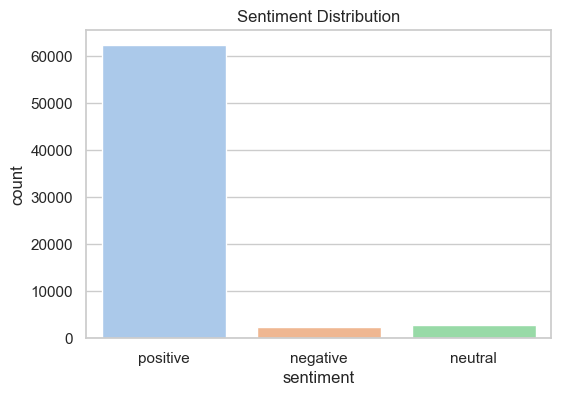

In [8]:
# Sentiment Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df, palette='pastel')
plt.title("Sentiment Distribution")
plt.show()

#### Observation: Positive reviews dominate; negative and neutral reviews are fewer.

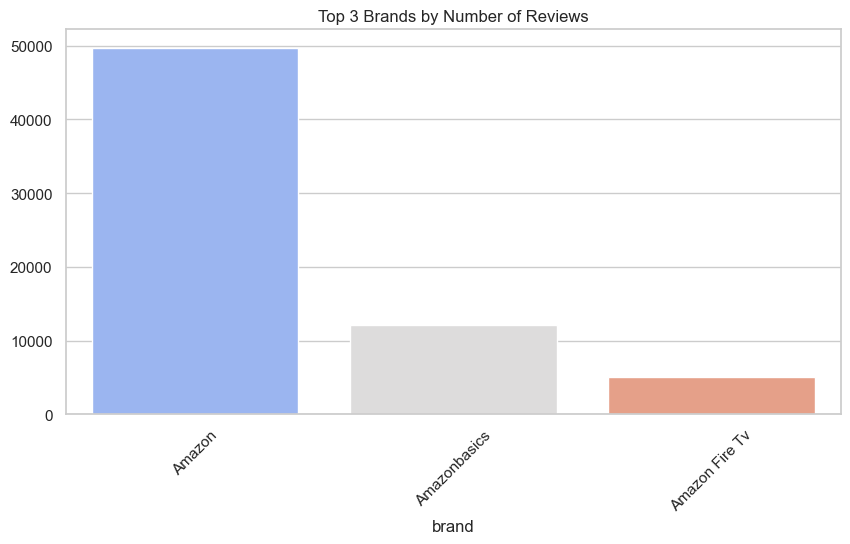

In [9]:
# Top 3 Brands by Review Count
top_brands = df['brand'].value_counts().head(3)
plt.figure(figsize=(10,5))
sns.barplot(x=top_brands.index, y=top_brands.values, palette='coolwarm')
plt.xticks(rotation=45)
plt.title("Top 3 Brands by Number of Reviews")
plt.show()

#### Observation: Some brands dominate the dataset in terms of review count.

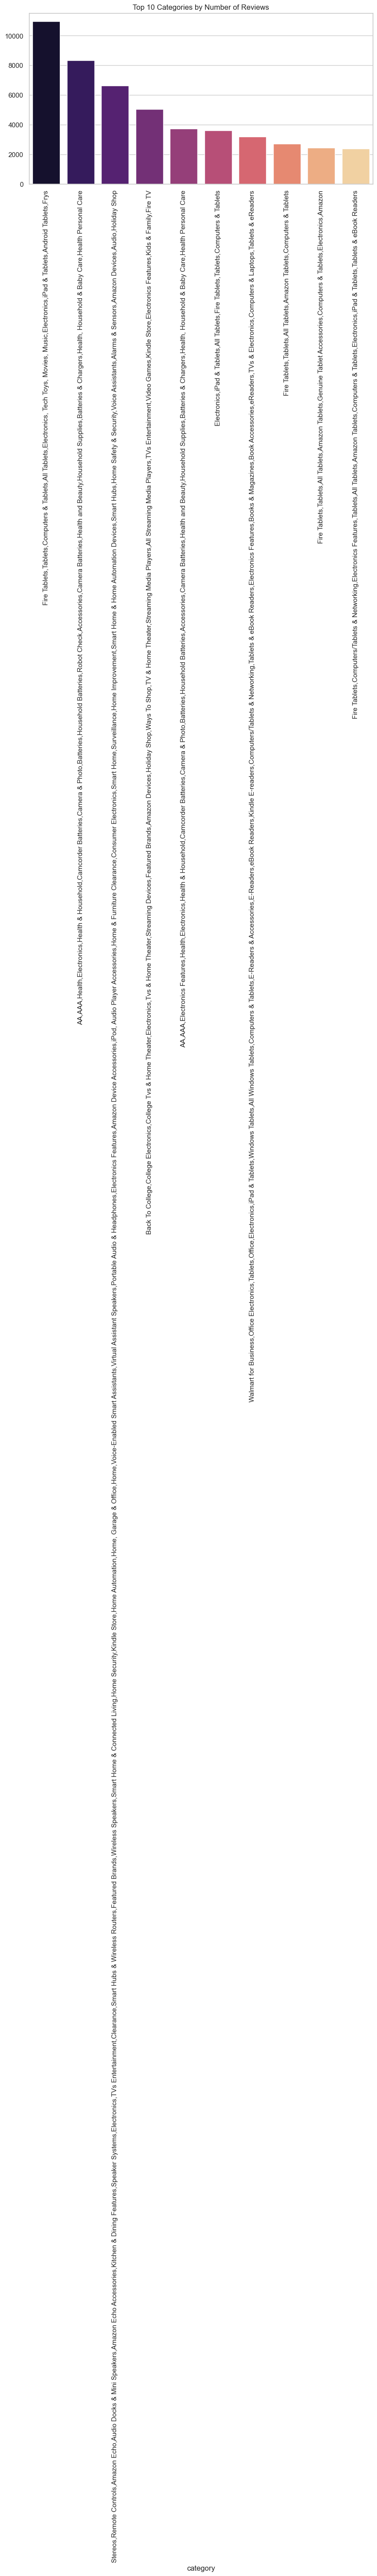

In [10]:
# Top 10 Categories by Review Count
top_categories = df['category'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_categories.index, y=top_categories.values, palette='magma')
plt.xticks(rotation=90)
plt.title("Top 10 Categories by Number of Reviews")
plt.show()

#### Observation: Electronics and tablets have the most reviews.

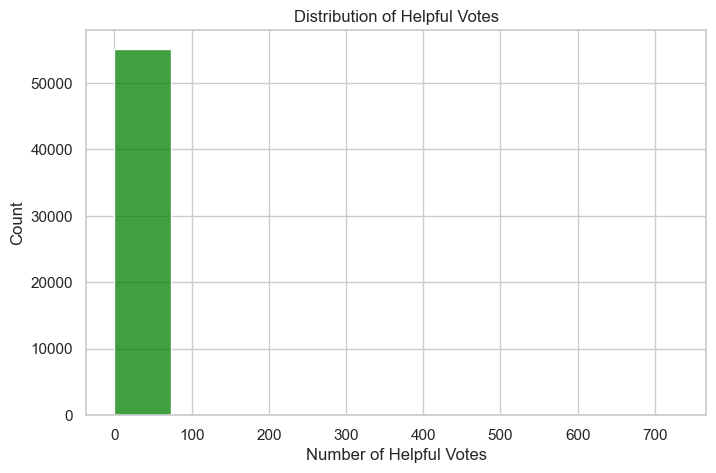

In [12]:
# Helpful Votes Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['reviews.numHelpful'].dropna(), bins=10, kde=False, color='green')
plt.title("Distribution of Helpful Votes")
plt.xlabel("Number of Helpful Votes")
plt.show()

#### Observation: Most reviews have 0 helpful votes; a few reviews are highly rated by other users.

# Bivariate Analysis

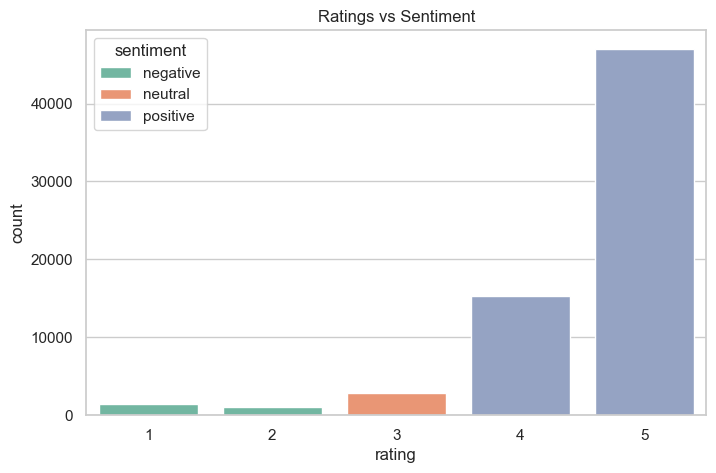

In [13]:
# Ratings vs Sentiment
plt.figure(figsize=(8,5))
sns.countplot(x='rating', hue='sentiment', data=df, palette='Set2')
plt.title("Ratings vs Sentiment")
plt.show()

#### Observation: Positive sentiment aligns with higher ratings; negative reviews mostly 1-2 stars.

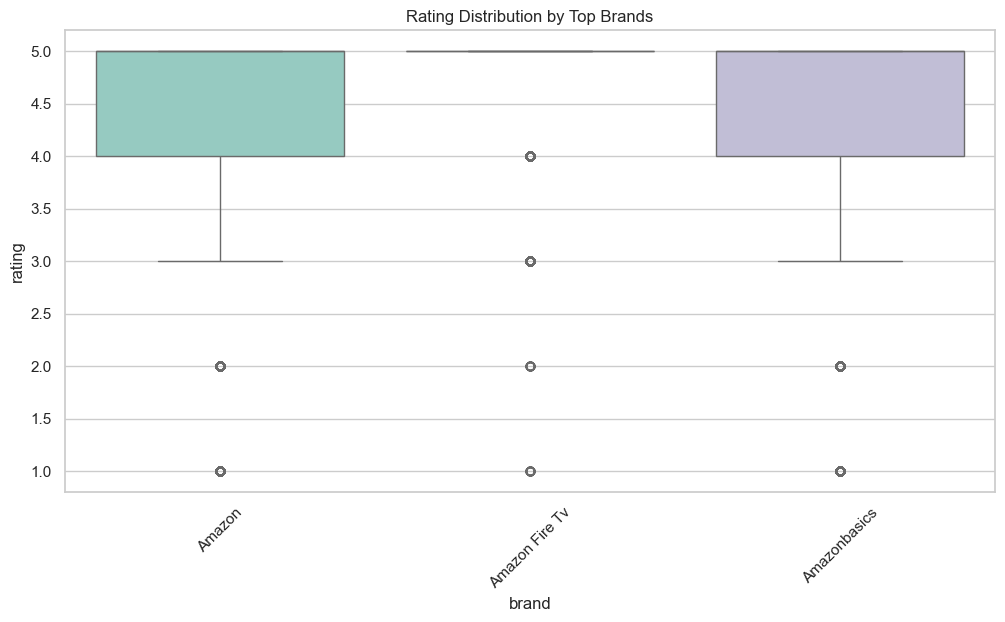

In [14]:
# Rating Distribution by Top Brands
plt.figure(figsize=(12,6))
sns.boxplot(x='brand', y='rating', data=df[df['brand'].isin(top_brands.index)], palette='Set3')
plt.title("Rating Distribution by Top Brands")
plt.xticks(rotation=45)
plt.show()

#### Observation: Some brands maintain consistently high ratings; some have wider variation.

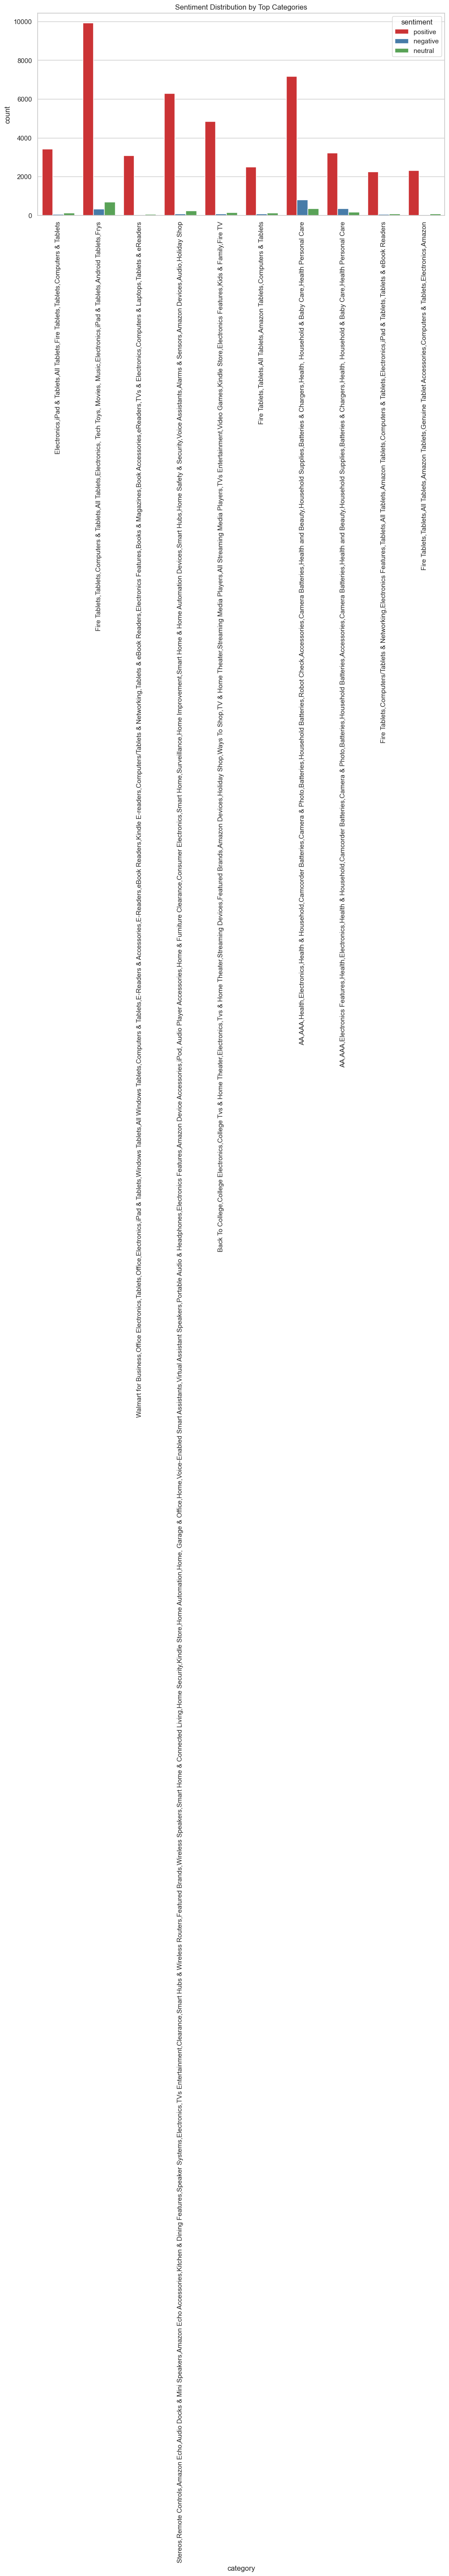

In [15]:
# Sentiment by Category
plt.figure(figsize=(12,6))
sns.countplot(x='category', hue='sentiment', data=df[df['category'].isin(top_categories.index)], palette='Set1')
plt.title("Sentiment Distribution by Top Categories")
plt.xticks(rotation=90)
plt.show()

#### Observation: Certain categories have higher negative sentiment; useful for targeted analysis.

# Text Analysis

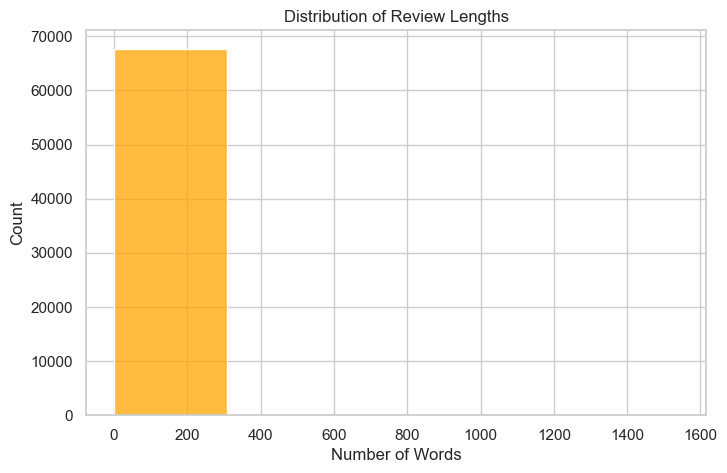

In [17]:
# 6a. Review Length Distribution
df['review_length'] = df['clean_text'].astype(str).apply(lambda x: len(x.split()))
plt.figure(figsize=(8,5))
sns.histplot(df['review_length'], bins=5, color='orange')
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.show()

#### Observation: Most reviews are short (<50 words); some long reviews provide detailed feedback.

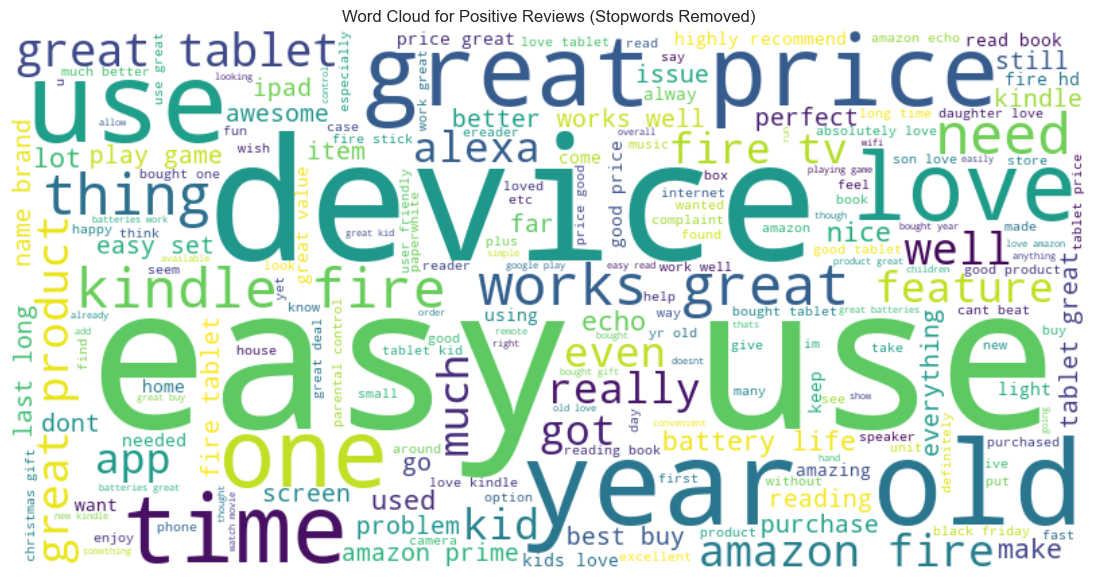

In [19]:
# Word Cloud for Positive Reviews
positive_text = " ".join(df[df['sentiment']=='positive']['clean_text'].astype(str)).lower()
positive_text = re.sub(r'[^a-z\s]', '', positive_text)
positive_words = [word for word in positive_text.split() if word not in stop_words]

wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(" ".join(positive_words))
plt.figure(figsize=(15,7))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud for Positive Reviews (Stopwords Removed)")
plt.show()

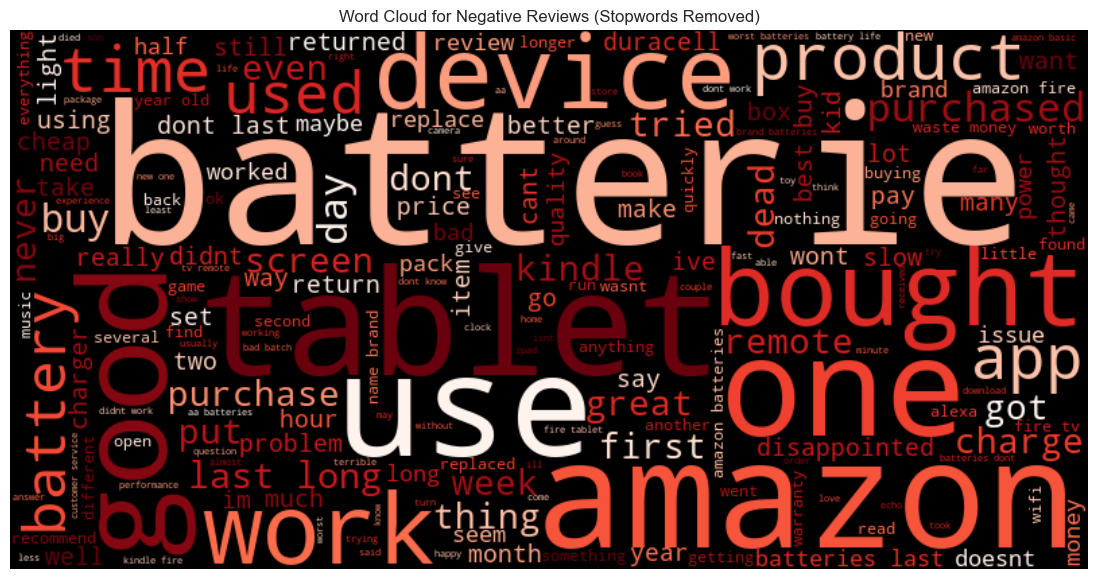

In [20]:
# Word Cloud for Negative Reviews 
negative_text = " ".join(df[df['sentiment']=='negative']['clean_text'].astype(str)).lower()
negative_text = re.sub(r'[^a-z\s]', '', negative_text)
negative_words = [word for word in negative_text.split() if word not in stop_words]

wordcloud_neg = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(" ".join(negative_words))
plt.figure(figsize=(15,7))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud for Negative Reviews (Stopwords Removed)")
plt.show()

In [21]:
# Most Frequent Words Overall 
all_text = " ".join(df['clean_text'].astype(str)).lower()
all_text = re.sub(r'[^a-z\s]', '', all_text)
filtered_words = [word for word in all_text.split() if word not in stop_words]

counter = Counter(filtered_words)
print("Top 20 most frequent meaningful words in reviews:")
print(counter.most_common(20))

Top 20 most frequent meaningful words in reviews:
[('great', 22622), ('tablet', 16829), ('use', 13026), ('good', 11466), ('love', 11149), ('amazon', 9944), ('easy', 9822), ('price', 9712), ('bought', 8984), ('kindle', 8610), ('one', 8385), ('batteries', 8083), ('fire', 7341), ('like', 6738), ('product', 6013), ('kids', 5692), ('would', 5657), ('loves', 5354), ('well', 5319), ('get', 5155)]


# Insights Summary

1. Ratings are skewed toward 4-5 stars, reflecting positive bias common in Amazon reviews.
2. Sentiment distribution aligns reasonably with rating values.
3. Top brands dominate review count, and ratings vary slightly by brand.
4. Categories show different sentiment distributions — useful for targeted analysis.
5. Most reviews are short (<50 words), but longer reviews exist.
6. WordClouds highlight key terms for positive and negative reviews (stopwords removed).
7. Frequent word analysis helps identify common product features mentioned by users.
